# Import Library

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

import tf_keras as keras
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
import lightgbm as lgb

from transformers import (BertTokenizer, TFBertForSequenceClassification,
                          RobertaTokenizer, TFRobertaForSequenceClassification,
                          AlbertTokenizer, TFAlbertForSequenceClassification,
                          create_optimizer)
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

2025-04-12 18:36:08.274945: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-12 18:36:08.485159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744457768.565529    6237 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744457768.589688    6237 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744457768.759747    6237 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

# Train Test Split

In [3]:
df = pd.read_csv('../data/processed/vader_reviews_finance.csv')
full_train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(full_train_df, test_size=0.25, random_state=42)

**Key Takepoint(s)**:
- Pemisahan data akan dilakukan menggunakan holdout validation menjadi train, val, dan test karena data berjumlah banyak dan untuk menggantikan kebutuhan cross-validation.
- Pada notebook ini digunakan [dataset yang dilabel menggunakan vader](../data/processed/vader_reviews_finance.csv).


# Data Preprocessing

In [4]:
print(f"Ukuran Train set: {len(train_df)}")
print(f"Ukuran Validation set: {len(val_df)}")
print(f"Ukuran Test set: {len(test_df)}")

label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping)
test_df['label'] = test_df['label'].map(label_mapping)

print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

Ukuran Train set: 37137
Ukuran Validation set: 12380
Ukuran Test set: 12380
label
2    21527
0    11632
1     3978
Name: count, dtype: int64
label
2    7106
0    3946
1    1328
Name: count, dtype: int64
label
2    7285
0    3769
1    1326
Name: count, dtype: int64


In [5]:
def encode_texts(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        truncation=True,
        padding="max_length",
        return_tensors="tf"
    )

In [ ]:
def create_tf_dataset(encodings, labels, batch_size=16, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((
        dict(encodings),
        labels
    ))
    if shuffle:
        dataset = dataset.shuffle(1000)
    return dataset.batch(batch_size)

def plot_learning_curves(history, title='Model'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Akurasi Training')
    plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
    plt.title(f'Akurasi {title}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

In [7]:
models_dict = {}
test_dataset_dict = {}

# Feature Extraction Deep Learning

## BERT Embeddings

In [8]:
bert_config = {
    'model_name': 'bert-base-uncased',
    'batch_size': 16,
    'learning_rate': 2e-5,
    'epochs': 5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'dropout': 0.1,
    'beta_1': 0.9,
    'beta_2': 0.999,
    'epsilon': 1e-6,
    'clip_norm': 1.0,
}


In [9]:
bert_tokenizer = BertTokenizer.from_pretrained(bert_config['model_name'])

In [10]:
for i, text in enumerate(train_df['text']):
    token_count = len(bert_tokenizer.encode(text, truncation=False))
    if token_count > 512:
        print(f"Index {i}: {token_count} tokens")
        print(text[:200], '...\n')  

Token indices sequence length is longer than the specified maximum sequence length for this model (582 > 512). Running this sequence through the model will result in indexing errors


Index 5540: 582 tokens
ok update i found you have to click resend twice if you send a screen shot of issues so thats a app issue that need to auto resend at least twice in the background as it confuses you then to add money ...

Index 21207: 676 tokens
reply how is it a risk product as none of you script readers seems to be able to actually explain why it is classed as a risk product just that it is and if contactless is a risk product why am i allo ...



In [11]:
MAX_ALLOWED_TOKENS = 512

def is_too_long(text):
    return len(bert_tokenizer.encode(text, truncation=False)) > MAX_ALLOWED_TOKENS

In [12]:
train_df = train_df[~train_df['text'].apply(is_too_long)].reset_index(drop=True)
val_df = val_df[~val_df['text'].apply(is_too_long)].reset_index(drop=True) 
test_df = test_df[~test_df['text'].apply(is_too_long)].reset_index(drop=True) 

In [13]:
train_lengths = [len(bert_tokenizer.encode(text, truncation=False)) for text in train_df['text']]
val_lengths = [len(bert_tokenizer.encode(text, truncation=False)) for text in val_df['text']]
test_lengths = [len(bert_tokenizer.encode(text, truncation=False)) for text in test_df['text']]

all_lengths = train_lengths + val_lengths + test_lengths

print(f"Panjang token maksimum: {np.max(all_lengths)}")
print(f"95th percentile: {np.percentile(all_lengths, 95)}")
print(f"99th percentile: {np.percentile(all_lengths, 99)}")

Panjang token maksimum: 388
95th percentile: 96.0
99th percentile: 106.0


In [14]:
train_labels = tf.convert_to_tensor(train_df['label'].values)
val_labels = tf.convert_to_tensor(val_df['label'].values)
test_labels = tf.convert_to_tensor(test_df['label'].values)

I0000 00:00:1744457850.935564    6237 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [15]:
bert_train_encodings = encode_texts(train_df['text'], bert_tokenizer)
bert_val_encodings = encode_texts(val_df['text'], bert_tokenizer)
bert_test_encodings = encode_texts(test_df['text'], bert_tokenizer)

bert_train_dataset = create_tf_dataset(bert_train_encodings, train_labels, batch_size=bert_config['batch_size'])
bert_val_dataset = create_tf_dataset(bert_val_encodings, val_labels, batch_size=bert_config['batch_size'], shuffle=False)
bert_test_dataset = create_tf_dataset(bert_test_encodings, test_labels, batch_size=bert_config['batch_size'], shuffle=False)

test_dataset_dict['BERT'] = bert_test_dataset

# RoBERTa Embeddings

In [16]:
roberta_config = {
    'model_name': 'roberta-base',
    'batch_size': 16,
    'learning_rate': 2e-5,
    'epochs': 5,
    'weight_decay': 0.1,
    'warmup_ratio': 0.1,
    'dropout': 0.1,
    'beta_1': 0.9,
    'beta_2': 0.98,
    'epsilon': 1e-6,
}


In [17]:
roberta_tokenizer = RobertaTokenizer.from_pretrained(roberta_config['model_name'])

roberta_train_encodings = encode_texts(train_df['text'], roberta_tokenizer)
roberta_val_encodings = encode_texts(val_df['text'], roberta_tokenizer)
roberta_test_encodings = encode_texts(test_df['text'], roberta_tokenizer)

roberta_train_dataset = create_tf_dataset(roberta_train_encodings, train_labels, batch_size=roberta_config['batch_size'])
roberta_val_dataset = create_tf_dataset(roberta_val_encodings, val_labels, batch_size=roberta_config['batch_size'], shuffle=False)
roberta_test_dataset = create_tf_dataset(roberta_test_encodings, test_labels, batch_size=roberta_config['batch_size'], shuffle=False)

test_dataset_dict['RoBERTa'] = roberta_test_dataset

In [18]:
# albert_config = {
#     'model_name': 'albert-base-v2',
#     'batch_size': 16,
#     'learning_rate': 2e-5,
#     'epochs': 5,
#     'warmup_ratio': 0.1,
#     'beta_1': 0.9,
#     'beta_2': 0.999,
#     'epsilon': 1e-6,
#     'clip_norm': 1.0,
# }


In [19]:
# albert_tokenizer = AlbertTokenizer.from_pretrained(albert_config['model_name'])

# albert_train_encodings = encode_texts(train_df['text'], albert_tokenizer)
# albert_val_encodings = encode_texts(val_df['text'], albert_tokenizer)
# albert_test_encodings = encode_texts(test_df['text'], albert_tokenizer)

# albert_train_dataset = create_tf_dataset(albert_train_encodings, train_labels, batch_size=albert_config['batch_size'])
# albert_val_dataset = create_tf_dataset(albert_val_encodings, val_labels, batch_size=albert_config['batch_size'], shuffle=False)
# albert_test_dataset = create_tf_dataset(albert_test_encodings, test_labels, batch_size=albert_config['batch_size'], shuffle=False)

# test_dataset_dict['ALBERT'] = albert_test_dataset


**Key Takepoint(s)**:
- Parameter dari BERT dan RoBERTa diinisialisasi sesuai dengan saran dari penelitian [Mosbach et al. (2021)](https://arxiv.org/abs/2006.04884). 
- Khusus untuk jumlah iterasi atau epoch pelatihan, saya akan mengikuti saran penulis asli dari model BERT, yakni [Devlin et al. (2019)](https://arxiv.org/abs/1810.04805) yang menyarankan BERT untuk dilatih sekitar 2 sampai 4 epoch. 
- Saya memilih 5 epoch dengan early stopping dibantu checkpoint nantinya untuk menentukan iterasi terbaik.
- Kedua model akan dilatih secara fine-tuning mengikuti penilitian [Mosbach et al. (2021)](https://arxiv.org/abs/2006.04884). 

![image](../image.png)

**✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [x] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur / split / label)
  - [ ] Skema 1: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 2: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 3: (Algoritma, Fitur, Split, Akurasi)
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal


# Modelling Deep Learning 

## BERT

In [20]:
bert_model = TFBertForSequenceClassification.from_pretrained(bert_config['model_name'], num_labels=3, hidden_dropout_prob=bert_config['dropout'],
    attention_probs_dropout_prob=bert_config['dropout'])

bert_steps_per_epoch = len(train_df) // bert_config['batch_size']
bert_total_steps = bert_steps_per_epoch * bert_config['epochs']
bert_warmup_steps = int(bert_config['warmup_ratio'] * bert_total_steps)

bert_optimizer, _ = create_optimizer(
    init_lr=bert_config['learning_rate'],
    num_train_steps=bert_total_steps,
    weight_decay_rate=bert_config['weight_decay'],
    num_warmup_steps=bert_warmup_steps,
    adam_beta1=bert_config['beta_1'],
    adam_beta2=bert_config['beta_2'],
    adam_epsilon=bert_config['epsilon'],
    adam_clipnorm=bert_config['clip_norm'],
)

bert_model.compile(
    optimizer=bert_optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


bert_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../checkpoints/bert_model_epoch-{epoch:02d}_val_acc-{val_accuracy:.4f}.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True, 
        mode="min",
    ), 
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        mode="min",
        verbose=1
    )
]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
bert_history = bert_model.fit(
    bert_train_dataset,
    validation_data=bert_val_dataset,
    epochs=bert_config['epochs'],
    callbacks=bert_callbacks
)

Epoch 1/5
2321/2321 [==============================] - ETA: 0s - loss: 0.4517 - accuracy: 0.8127

/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


2321/2321 [==============================] - 708s 298ms/step - loss: 0.4517 - accuracy: 0.8127 - val_loss: 0.2473 - val_accuracy: 0.9155
Epoch 2/5
2321/2321 [==============================] - 710s 306ms/step - loss: 0.1873 - accuracy: 0.9381 - val_loss: 0.2050 - val_accuracy: 0.9329
Epoch 3/5
2321/2321 [==============================] - 24045s 10s/step - loss: 0.1131 - accuracy: 0.9609 - val_loss: 0.1941 - val_accuracy: 0.9394
Epoch 4/5
2321/2321 [==============================] - 702s 302ms/step - loss: 0.0731 - accuracy: 0.9744 - val_loss: 0.2915 - val_accuracy: 0.9314
Epoch 5/5
2321/2321 [==============================] - 695s 300ms/step - loss: 0.0476 - accuracy: 0.9837 - val_loss: 0.2445 - val_accuracy: 0.9351
Epoch 5: early stopping


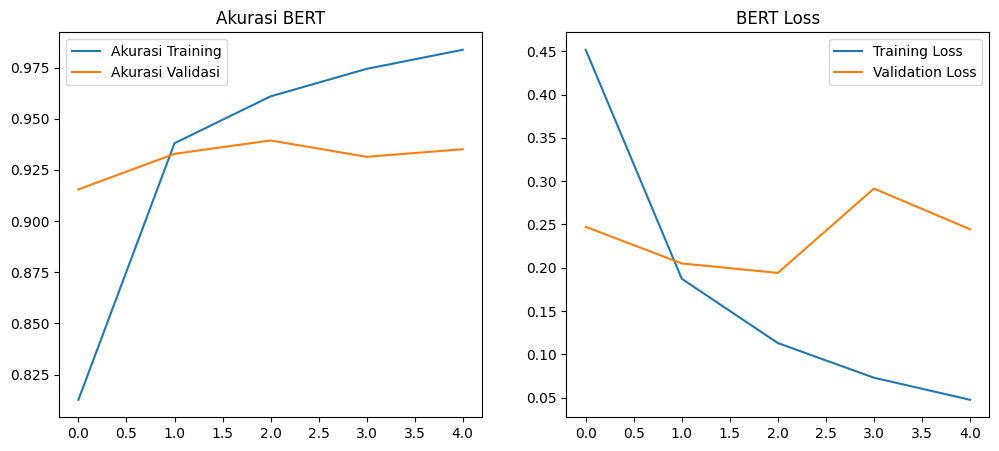

In [ ]:
plot_learning_curves(bert_history, title='BERT')

In [21]:
models_dict['BERT'] = {
    'model': bert_model,
}

# RoBERTa 

In [22]:
roberta_model = TFRobertaForSequenceClassification.from_pretrained(roberta_config['model_name'], num_labels=3, hidden_dropout_prob=roberta_config['dropout'],
    attention_probs_dropout_prob=roberta_config['dropout'])

roberta_steps_per_epoch = len(train_df) // roberta_config['batch_size']
roberta_total_steps = roberta_steps_per_epoch * roberta_config['epochs']
roberta_warmup_steps = int(roberta_config['warmup_ratio'] * roberta_total_steps)

roberta_optimizer, _ = create_optimizer(
    init_lr=roberta_config['learning_rate'],
    num_train_steps=roberta_total_steps,
    weight_decay_rate=roberta_config['weight_decay'],
    num_warmup_steps=roberta_warmup_steps,
    adam_beta1=roberta_config['beta_1'],
    adam_beta2=roberta_config['beta_2'],
    adam_epsilon=roberta_config['epsilon'],
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [23]:
roberta_model.compile(
    optimizer=roberta_optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [24]:
roberta_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../checkpoints/roberta_model_epoch-{epoch:02d}_val_acc-{val_accuracy:.4f}.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True, 
        mode="min",
    ), 
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        mode="min",
        verbose=1
    )
]

In [27]:
roberta_history = roberta_model.fit(
    roberta_train_dataset,
    validation_data=roberta_val_dataset,
    epochs=roberta_config['epochs'],
    callbacks=roberta_callbacks
)

Epoch 1/5
2321/2321 [==============================] - ETA: 0s - loss: 0.4860 - accuracy: 0.8100

/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


2321/2321 [==============================] - 706s 298ms/step - loss: 0.4860 - accuracy: 0.8100 - val_loss: 0.3059 - val_accuracy: 0.8852
Epoch 2/5
2321/2321 [==============================] - 688s 296ms/step - loss: 0.2457 - accuracy: 0.9170 - val_loss: 0.2561 - val_accuracy: 0.9166
Epoch 3/5
2321/2321 [==============================] - 692s 298ms/step - loss: 0.1679 - accuracy: 0.9440 - val_loss: 0.2072 - val_accuracy: 0.9340
Epoch 4/5
2321/2321 [==============================] - 697s 300ms/step - loss: 0.1211 - accuracy: 0.9592 - val_loss: 0.2139 - val_accuracy: 0.9379
Epoch 5/5
2321/2321 [==============================] - 689s 297ms/step - loss: 0.0878 - accuracy: 0.9702 - val_loss: 0.2128 - val_accuracy: 0.9392
Epoch 5: early stopping


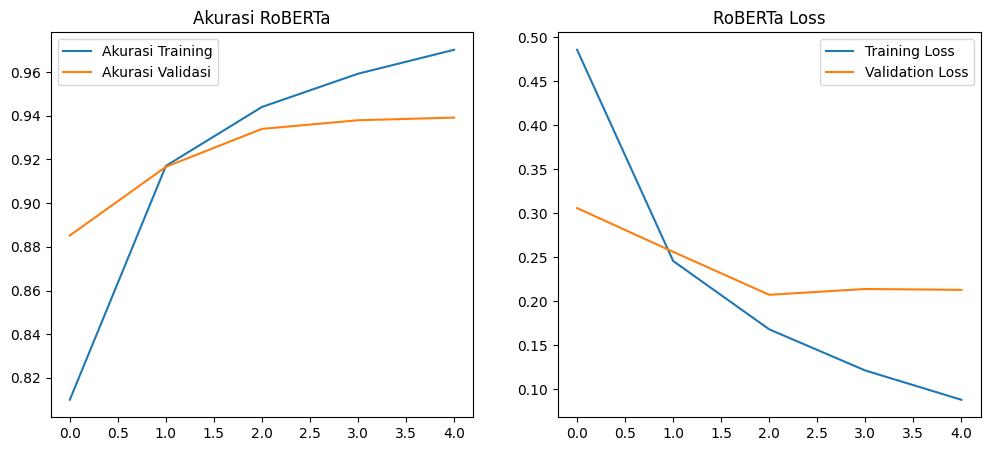

In [28]:
plot_learning_curves(roberta_history, title='RoBERTa')

In [25]:
models_dict['RoBERTa'] = {
    'model': roberta_model,
}

In [ ]:
# albert_model = TFAlbertForSequenceClassification.from_pretrained(albert_config['model_name'], num_labels=3)

# albert_steps_per_epoch = len(train_df) // albert_config['batch_size']
# albert_total_steps = albert_steps_per_epoch * albert_config['epochs']
# albert_warmup_steps = int(albert_config['warmup_ratio'] * albert_total_steps)

# albert_optimizer, _ = create_optimizer(
#     init_lr=albert_config['learning_rate'],
#     num_train_steps=albert_total_steps,
#     num_warmup_steps=albert_warmup_steps,
#     adam_beta1=albert_config['beta_1'],
#     adam_beta2=albert_config['beta_2'],
#     adam_epsilon=albert_config['epsilon'],
#     adam_clipnorm=albert_config['clip_norm'],
# )

# albert_model.compile(
#     optimizer=albert_optimizer,
#     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=['accuracy']
# )

# albert_callbacks = [
#     keras.callbacks.ModelCheckpoint(
#         filepath="../checkpoints/albert_model_epoch-{epoch:02d}_val_acc-{val_accuracy:.4f}.weights.h5",
#         monitor="val_loss",
#         save_best_only=True,
#         save_weights_only=True, 
#         mode="min",
#     ), 
#     keras.callbacks.EarlyStopping(
#         monitor="val_loss",
#         patience=2,
#         mode="min",
#         verbose=1
#     )
# ]


All PyTorch model weights were used when initializing TFAlbertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFAlbertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# albert_history = albert_model.fit(
#     albert_train_dataset,
#     validation_data=albert_val_dataset,
#     epochs=albert_config['epochs'],
#     callbacks=albert_callbacks
# )

Epoch 1/5


I0000 00:00:1744383393.676996    2002 service.cc:152] XLA service 0x7f024c483480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744383393.678702    2002 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-04-11 21:56:33.752944: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744383393.828585    2002 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744383394.030812    2002 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2321/2321 [==============================] - 803s 338ms/step - loss: 0.4751 - accuracy: 0.8171 - val_loss: 0.2816 - val_accuracy: 0.9000
Epoch 2/5
2321/2321 [==============================] - 766s 330ms/step - loss: 0.2518 - accuracy: 0.9223 - val_loss: 0.1883 - val_accuracy: 0.9462
Epoch 3/5
2321/2321 [==============================] - 753s 325ms/step - loss: 0.1833 - accuracy: 0.9454 - val_loss: 0.1568 - val_accuracy: 0.9598
Epoch 4/5
2321/2321 [==============================] - 779s 335ms/step - loss: 0.1383 - accuracy: 0.9609 - val_loss: 0.1213 - val_accuracy: 0.9674
Epoch 5/5
2321/2321 [==============================] - 788s 339ms/step - loss: 0.1004 - accuracy: 0.9720 - val_loss: 0.0766 - val_accuracy: 0.9798


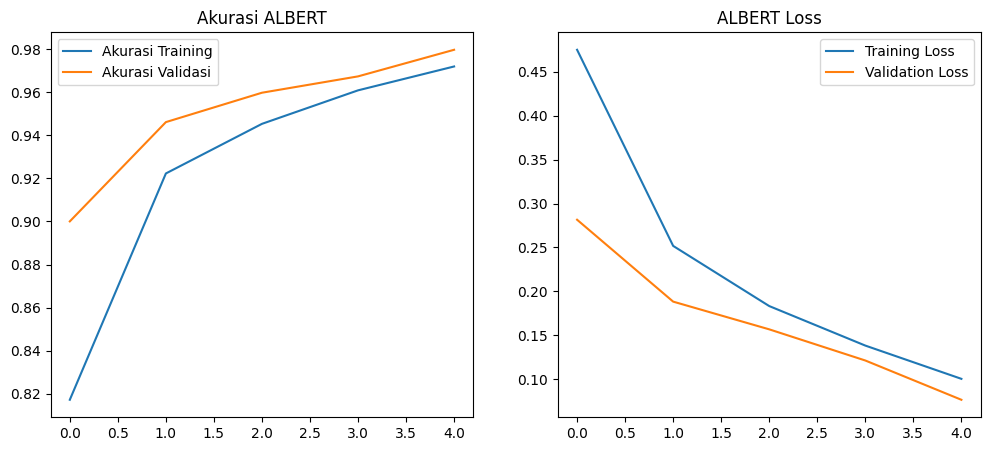

In [ ]:
# plot_learning_curves(albert_history, title='ALBERT')

# models_dict['ALBERT'] = {
#     'model': albert_model,
# }

# Modeling Machine Learning

In [26]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 1),
    min_df=5,  
    max_df=0.6,
    binary=True, 
    use_idf=False  
)

X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_val_tfidf = tfidf.transform(val_df['text'])
X_test_tfidf = tfidf.transform(test_df['text'])

In [27]:
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

In [28]:
params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 70,
    'max_depth': -1,
    'min_child_samples': 25,
    'n_jobs': -1,
    'verbosity': -1,
    'random_state': 42,
    'min_data_in_leaf': 12,
    'feature_fraction': 0.6,  
}


In [29]:
lgb_model = lgb.LGBMClassifier(**params, n_estimators=500)
lgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_train_tfidf, y_train), (X_val_tfidf, y_val)],
    eval_metric=['multi_logloss', 'multi_error'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(10)
    ]
)

Training until validation scores don't improve for 30 rounds
[10]	training's multi_error: 0.338926	training's multi_logloss: 0.732931	valid_1's multi_error: 0.349919	valid_1's multi_logloss: 0.743643
[20]	training's multi_error: 0.223886	training's multi_logloss: 0.625427	valid_1's multi_error: 0.242084	valid_1's multi_logloss: 0.642709
[30]	training's multi_error: 0.186859	training's multi_logloss: 0.558203	valid_1's multi_error: 0.206866	valid_1's multi_logloss: 0.582904
[40]	training's multi_error: 0.167335	training's multi_logloss: 0.510413	valid_1's multi_error: 0.190226	valid_1's multi_logloss: 0.542358
[50]	training's multi_error: 0.15546	training's multi_logloss: 0.473588	valid_1's multi_error: 0.180695	valid_1's multi_logloss: 0.513738
[60]	training's multi_error: 0.146412	training's multi_logloss: 0.443463	valid_1's multi_error: 0.174233	valid_1's multi_logloss: 0.49243
[70]	training's multi_error: 0.138818	training's multi_logloss: 0.418869	valid_1's multi_error: 0.168174	va

LGBMClassifier(feature_fraction=0.6, learning_rate=0.05, metric='multi_logloss',
               min_child_samples=25, min_data_in_leaf=12, n_estimators=500,
               n_jobs=-1, num_class=3, num_leaves=70, objective='multiclass',
               random_state=42, verbosity=-1)

In [30]:
lgb_test_preds = lgb_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, lgb_test_preds)
print(f"Test accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test, lgb_test_preds))

Test accuracy: 0.8583

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3769
           1       0.85      0.77      0.81      1326
           2       0.89      0.91      0.90      7285

    accuracy                           0.86     12380
   macro avg       0.85      0.82      0.83     12380
weighted avg       0.86      0.86      0.86     12380



/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [31]:
lgb_results = lgb_model.evals_result_

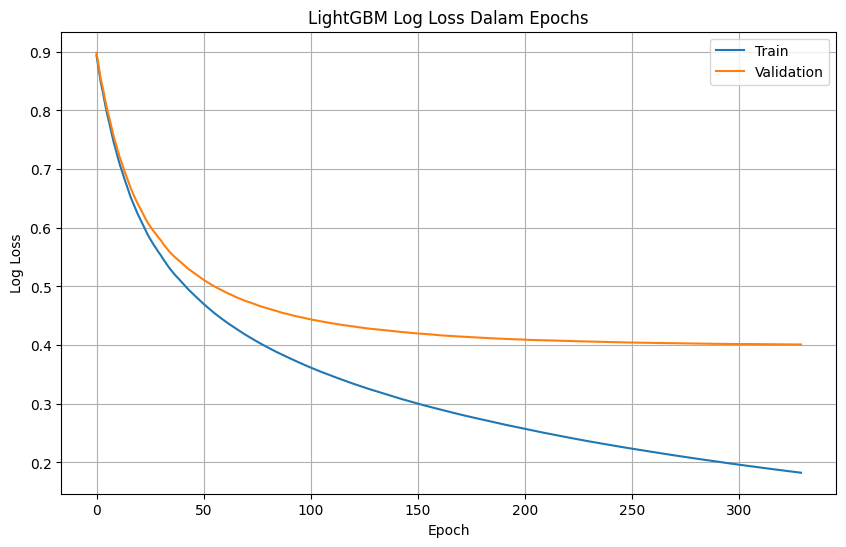

In [32]:
epochs = len(lgb_results['training']['multi_logloss'])
x_axis = range(epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, lgb_results['training']['multi_logloss'], label='Train')
plt.plot(x_axis, lgb_results['valid_1']['multi_logloss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('LightGBM Log Loss Dalam Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
lgb_train_preds = lgb_model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, lgb_train_preds)
train_accuracy

/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9598491988689916

**Key Takepoint(s)**:
- Terlihat dari learning curve bahwa model BERT dan RoBERTa mengalami sangat cepat mengalami convergence, namun mengalami overfitting setelah 2 epoch.
- Terlihat dari learning curve model LightGBM juga mengalami overfitting.
- Keduanya dapat melakukan klasifikasi dengan cukup baik walaupun dataset yang digunakan mengalami class imbalance.

**✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [x] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur extraction / split / label)
  - [ ] Skema 1: (BERT, Tokenizer BERT, 60/20/20, Akurasi)
  - [ ] Skema 2: (RoBERTa, Tokenizer RoBERTa,60/20/20, Akurasi)
  - [ ] Skema 3: (LightGBM, TF-IDF, 60/20/20, Akurasi)
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal


# Evaluasi

In [34]:
def evaluate_model(model, train_dataset, test_dataset, train_labels, test_labels, model_name):
    test_predictions = model.predict(test_dataset)
    test_pred_labels = np.argmax(test_predictions.logits, axis=1)
    test_accuracy = accuracy_score(test_labels, test_pred_labels)
    
    train_predictions = model.predict(train_dataset)
    train_pred_labels = np.argmax(train_predictions.logits, axis=1)
    train_accuracy = accuracy_score(train_labels, train_pred_labels)
    
    print(f"\nAkurasi Train {model_name}: {train_accuracy:.4f}")
    print(f"\nAkurasi Test {model_name}: {test_accuracy:.4f}")
    print(classification_report(test_labels, test_pred_labels))
    
    return test_accuracy, train_accuracy

def evaluate_dl_models(best_models_dict, train_dataset_dict, test_dataset_dict, train_labels, test_labels):
    best_results = {}
    for model_name, model in best_models_dict.items():
        print(f"\nMengevaluasi {model_name}...")
        test_accuracy, train_accuracy = evaluate_model(
            model,
            train_dataset_dict[model_name],
            test_dataset_dict[model_name],
            train_labels,
            test_labels,
            f"{model_name} (Best Checkpoint)"
        )
        best_results[model_name] = {
            'akurasi_test': test_accuracy,
            'akurasi_train': train_accuracy
        }
    
    best_results_df = pd.DataFrame.from_dict(best_results, orient='index')
    best_results_df = best_results_df.reset_index().rename(columns={'index': 'model'})
    return best_results_df

def evaluate_ml_models(ml_models_dict, X_train_tfidf, X_test_tfidf, y_train, y_test):
    ml_results = {}
    
    for model_name, model in ml_models_dict.items():
        print(f"\nMengevaluasi {model_name}...")
        
        train_preds = model.predict(X_train_tfidf)
        test_preds = model.predict(X_test_tfidf)
        
        train_accuracy = accuracy_score(y_train, train_preds)
        test_accuracy = accuracy_score(y_test, test_preds)
        
        print(f"\nAkurasi Train {model_name}: {train_accuracy:.4f}")
        print(f"\nAkurasi Test {model_name}: {test_accuracy:.4f}")
        print(classification_report(y_test, test_preds))
        
        ml_results[model_name] = {
            'akurasi_train': train_accuracy,
            'akurasi_test': test_accuracy
        }
    
    ml_results_df = pd.DataFrame.from_dict(ml_results, orient='index')
    ml_results_df = ml_results_df.reset_index().rename(columns={'index': 'model'})
    return ml_results_df

In [35]:
ml_models_dict = {
    # 'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

In [36]:
ml_results_df = evaluate_ml_models(ml_models_dict, X_train_tfidf, X_test_tfidf, y_train, y_test)
ml_results_df


Mengevaluasi LightGBM...


/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Akurasi Train LightGBM: 0.9598

Akurasi Test LightGBM: 0.8583
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3769
           1       0.85      0.77      0.81      1326
           2       0.89      0.91      0.90      7285

    accuracy                           0.86     12380
   macro avg       0.85      0.82      0.83     12380
weighted avg       0.86      0.86      0.86     12380



/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,akurasi_train,akurasi_test
0,LightGBM,0.959849,0.85832


In [37]:
def load_best_checkpoint_model(model_type, checkpoint_path):
    if model_type == 'BERT':
        model = TFBertForSequenceClassification.from_pretrained(
            bert_config['model_name'], num_labels=3, hidden_dropout_prob=bert_config['dropout'],
    attention_probs_dropout_prob=bert_config['dropout'])
    elif model_type == 'RoBERTa':
        model = TFRobertaForSequenceClassification.from_pretrained(
            roberta_config['model_name'], num_labels=3, hidden_dropout_prob=roberta_config['dropout'],
    attention_probs_dropout_prob=roberta_config['dropout'])
    # elif model_type == 'ALBERT':
    #     model = TFAlbertForSequenceClassification.from_pretrained(
    #         albert_config['model_name'], num_labels=3)
    else:
        raise ValueError(f"Unknown model type: {model_type}")
        
    model.load_weights(checkpoint_path)
    
    if model_type == 'BERT':
        model.compile(
            optimizer=bert_optimizer,
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy']
        )
    elif model_type == 'RoBERTa':
        model.compile(
            optimizer=roberta_optimizer,
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy']
        )
    # elif model_type == 'ALBERT':
    #     model.compile(
    #         optimizer=albert_optimizer,
    #         loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    #         metrics=['accuracy']
    #     )
    
    return model

In [38]:
train_dataset_dict = {
    'BERT': create_tf_dataset(bert_train_encodings, train_labels, batch_size=bert_config['batch_size'], shuffle=False),
    'RoBERTa': create_tf_dataset(roberta_train_encodings, train_labels, batch_size=roberta_config['batch_size'], shuffle=False),
    # 'ALBERT': create_tf_dataset(albert_train_encodings, train_labels, batch_size=albert_config['batch_size'], shuffle=False)
}

In [39]:
import glob

def find_best_checkpoint(model_type):
    checkpoints = glob.glob(f"../checkpoints/{model_type.lower()}_model_*.weights.h5")
    if not checkpoints:
        raise FileNotFoundError(f"Tidak ditemukan checkpoint untuk {model_type}")
    
    best_checkpoint = sorted(checkpoints, 
                            key=lambda x: float(x.split('val_acc-')[1].split('.weights')[0]), 
                            reverse=True)[0]
    return best_checkpoint

best_models_dict = {}
try:
    bert_checkpoint = find_best_checkpoint('bert')
    best_models_dict['BERT'] = load_best_checkpoint_model('BERT', bert_checkpoint)
    print(f"Checkpoint BERT berhasil dimuat: {bert_checkpoint}")
except Exception as e:
    print(f"Gagal memuat checkpoint BERT: {e}")

try:
    roberta_checkpoint = find_best_checkpoint('roberta')
    best_models_dict['RoBERTa'] = load_best_checkpoint_model('RoBERTa', roberta_checkpoint)
    print(f"Checkpoint RoBERTa berhasil dimuat: {roberta_checkpoint}")
except Exception as e:
    print(f"Gagal memuat checkpoint RoBERTa: {e}")

# try:
#     albert_checkpoint = find_best_checkpoint('albert')
#     best_models_dict['ALBERT'] = load_best_checkpoint_model('ALBERT', albert_checkpoint)
#     print(f"Checkpoint ALBERT berhasil dimuat: {albert_checkpoint}")
except Exception as e:
    print(f"Gagal memuat checkpoint ALBERT: {e}")

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


Checkpoint BERT berhasil dimuat: ../checkpoints/bert_model_epoch-03_val_acc-0.9394.weights.h5


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

Checkpoint RoBERTa berhasil dimuat: ../checkpoints/roberta_model_epoch-03_val_acc-0.9340.weights.h5


In [40]:
best_results_df = evaluate_dl_models(best_models_dict, train_dataset_dict, test_dataset_dict, train_labels, test_labels)
ml_results_df = evaluate_ml_models(ml_models_dict, X_train_tfidf, X_test_tfidf, y_train, y_test)
all_results_df = pd.concat([best_results_df, ml_results_df], ignore_index=True)
all_results_df = all_results_df.sort_values(by='akurasi_test', ascending=False)

all_results_df


Mengevaluasi BERT...
2321/2321 [==============================] - 212s 91ms/step

Akurasi Train BERT (Best Checkpoint): 0.9625

Akurasi Test BERT (Best Checkpoint): 0.9615
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3769
           1       0.98      0.81      0.89      1326
           2       0.97      0.99      0.98      7285

    accuracy                           0.96     12380
   macro avg       0.96      0.92      0.94     12380
weighted avg       0.96      0.96      0.96     12380


Mengevaluasi RoBERTa...
2321/2321 [==============================] - 213s 92ms/step

Akurasi Train RoBERTa (Best Checkpoint): 0.9519

Akurasi Test RoBERTa (Best Checkpoint): 0.9511
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      3769
           1       0.97      0.80      0.87      1326
           2       0.96      0.98      0.97      7285

    accuracy                           0.95   

/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Akurasi Train LightGBM: 0.9598

Akurasi Test LightGBM: 0.8583
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3769
           1       0.85      0.77      0.81      1326
           2       0.89      0.91      0.90      7285

    accuracy                           0.86     12380
   macro avg       0.85      0.82      0.83     12380
weighted avg       0.86      0.86      0.86     12380



/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,akurasi_test,akurasi_train
0,BERT,0.961470,0.962515
1,RoBERTa,0.951131,0.951932
2,LightGBM,0.858320,0.959849


**✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [x] Menggunakan algoritma deep learning
- [x] Akurasi training ≥ 92%
- [x] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [x] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur extraction / split / label)
  - [x] Skema 1: (BERT, Tokenizer BERT, 60/20/20)
  - [x] Skema 2: (RoBERTa, Tokenizer RoBERTa, 60/20/20)
  - [x] Skema 3: (LightGBM, TF-IDF, 60/20/20)
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal

# Percobaan Inference

In [41]:
test_samples = pd.read_csv('../data/processed/vader_test_samples_finance.csv')
test_texts = test_samples['text'].tolist()
actual_labels = test_samples['label'].tolist()

label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
reverse_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
numeric_labels = [label_mapping[label] for label in actual_labels]

In [42]:
def predict_sentiment(texts, model_name, model, tokenizer=None, vectorizer=None):
    if model_name in ['BERT', 'RoBERTa']:
        encodings = tokenizer(
            texts,
            max_length=128,
            truncation=True,
            padding="max_length",
            return_tensors="tf"
        )
        
        tf_dataset = tf.data.Dataset.from_tensor_slices((
            dict(encodings)
        )).batch(len(texts))
        
        predictions = model.predict(tf_dataset)
        pred_labels = np.argmax(predictions.logits, axis=1)
    else:
        X_tfidf = vectorizer.transform(texts)
        pred_labels = model.predict(X_tfidf)
    
    return [reverse_mapping[label] for label in pred_labels], pred_labels




In [43]:
results = []

bert_pred_labels, bert_numeric_preds = predict_sentiment(
    test_texts, 'BERT', best_models_dict['BERT'], bert_tokenizer
)

roberta_pred_labels, roberta_numeric_preds = predict_sentiment(
    test_texts, 'RoBERTa', best_models_dict['RoBERTa'], roberta_tokenizer
)

lgb_pred_labels, lgb_numeric_preds = predict_sentiment(
    test_texts, 'LightGBM', lgb_model, vectorizer=tfidf
)

comparison_df = pd.DataFrame({
    'Text': test_texts,
    'Actual Label': actual_labels,
    'BERT Prediction': bert_pred_labels,
    'RoBERTa Prediction': roberta_pred_labels,
    'LightGBM Prediction': lgb_pred_labels
})



1/1 [==============================] - 2s 2s/step


/root/workspace/repos/dicoding-courses-final-project-archive/learn_machine_learning_development/.dicoding-lmld-venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [44]:
comparison_df

,Text,Actual Label,BERT Prediction,RoBERTa Prediction,LightGBM Prediction
0,very basic bank with a mediocre customer servi...,Positive,Positive,Positive,Positive
1,have been using revolute for a year now the ap...,Positive,Positive,Positive,Positive
2,i wish i could get an alert whenever i get mon...,Positive,Positive,Positive,Positive
3,takes so long to transfer money and sometimes ...,Neutral,Neutral,Neutral,Neutral
4,the app is generally reliable with most of the...,Neutral,Neutral,Neutral,Neutral
5,crashes my phone every time i open it forcing ...,Neutral,Neutral,Neutral,Neutral
6,up to now been great but its started having is...,Negative,Negative,Negative,Positive
7,just bought the high end one plus android phon...,Negative,Negative,Negative,Negative
8,terrible for paying cheques in constant error ...,Negative,Negative,Negative,Negative


In [ ]:
bert_accuracy = np.mean([1 if pred == actual else 0 for pred, actual in zip(bert_numeric_preds, numeric_labels)])
roberta_accuracy = np.mean([1 if pred == actual else 0 for pred, actual in zip(roberta_numeric_preds, numeric_labels)])
lgb_accuracy = np.mean([1 if pred == actual else 0 for pred, actual in zip(lgb_numeric_preds, numeric_labels)])

print(f"Akurasi BERT pada sampel pengujian: {bert_accuracy:.4f}")
print(f"Akurasi RoBERTa pada sampel pengujian: {roberta_accuracy:.4f}")
print(f"Akurasi LightGBM pada sampel pengujian: {lgb_accuracy:.4f}")

Akurasi BERT pada sampel pengujian: 1.0000
Akurasi RoBERTa pada sampel pengujian: 1.0000
Akurasi LightGBM pada sampel pengujian: 0.8889


**✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [x] Menggunakan algoritma deep learning
- [x] Akurasi training ≥ 92%
- [x] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [x] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur extraction / split / label)
  - [x] Skema 1: (BERT, Tokenizer BERT, 60/20/20)
  - [x] Skema 2: (RoBERTa, Tokenizer RoBERTa, 60/20/20)
  - [x] Skema 3: (LightGBM, TF-IDF, 60/20/20)
- [x] Cell inference untuk testing dengan output berupa kelas kategorikal

In [ ]:
python script/play_store_scraper.py <app_id> [opsi]